# Marketing ML Project

## Objectives
* Build a classifier that predicts wheter a person makes less than $50k or more than $50k given 40 demographic and employment related variables
* Create a segmentation model and demonstrate how the resulting groups differ from one another and how your client can use this model for marketing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, log_loss

## Import dataset

In [3]:
# read column headers into a list
with open('TakeHomeProject/census-bureau.columns', 'r') as f:
    columns = [line.strip() for line in f]

# import main data
df = pd.read_csv('TakeHomeProject/census-bureau.data', header=None, names=columns)

# display first few rows
df.head()

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,?,?,?,Not in universe under 1 year old,?,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,?,?,?,Not in universe under 1 year old,?,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [ ]:
columns

['age',
 'class of worker',
 'detailed industry recode',
 'detailed occupation recode',
 'education',
 'wage per hour',
 'enroll in edu inst last wk',
 'marital stat',
 'major industry code',
 'major occupation code',
 'race',
 'hispanic origin',
 'sex',
 'member of a labor union',
 'reason for unemployment',
 'full or part time employment stat',
 'capital gains',
 'capital losses',
 'dividends from stocks',
 'tax filer stat',
 'region of previous residence',
 'state of previous residence',
 'detailed household and family stat',
 'detailed household summary in household',
 'weight',
 'migration code-change in msa',
 'migration code-change in reg',
 'migration code-move within reg',
 'live in this house 1 year ago',
 'migration prev res in sunbelt',
 'num persons worked for employer',
 'family members under 18',
 'country of birth father',
 'country of birth mother',
 'country of birth self',
 'citizenship',
 'own business or self employed',
 "fill inc questionnaire for veteran's admin"

### Notes
* "Not in universe" used; a distinct category rather than "missing" data
* "?" indicates missing data
* "weight indicates relative distribution of people in general population that each record represents due to stratified sampling"
* complex decision boundary -> motivation for gradient boosted decision tree model classification task
* weighted k-means clustering for segmentation task since weights are important in identifying statistically significant segments

## Data Visualizations

In [ ]:
# preprocessing
df_clean = df.replace('?', 'NA') # handle missing values


In [ ]:
# feature engineering
df_clean['total_financial_flow'] = df_clean['capital gains'] - df_clean['capital losses'] + df_clean['dividends from stocks'] 

df_clean['life_productivity'] = df_clean['age'] * df_clean['weeks worked in year']

df_clean['employment_stability'] = df_clean['class of worker'].astype(str) + "_" + df_clean['education'].astype(str) # career category

# prime earning window where >$50K is statistically concentrated
df_clean['is_peak_earning_age'] = df_clean['age'].between(35, 55).astype(int)

In [ ]:
# separate features and convert target to binary
y = df_clean['label'].apply(lambda x:1 if '50000+' in str(x) else 0).values 
weights = df_clean['weight'].values # extract weights
X = df_clean.drop(['label', 'weight', 'year'], axis=1) # prepare features

In [ ]:
# encode categorical features as integers for xgboost
categorical = X.select_dtypes(include=['object']).columns
label_encoders = {}
for cat in categorical:
    le = LabelEncoder()
    X[cat] = le.fit_transform(X[cat].astype(str))
    label_encoders[cat] = le

In [ ]:
# temp dataframe that matches encoded feature set + target
X_vis = X.copy()
X_vis['target'] = y

# calculate correlation matrix
corr_matrix = X_vis.corr()

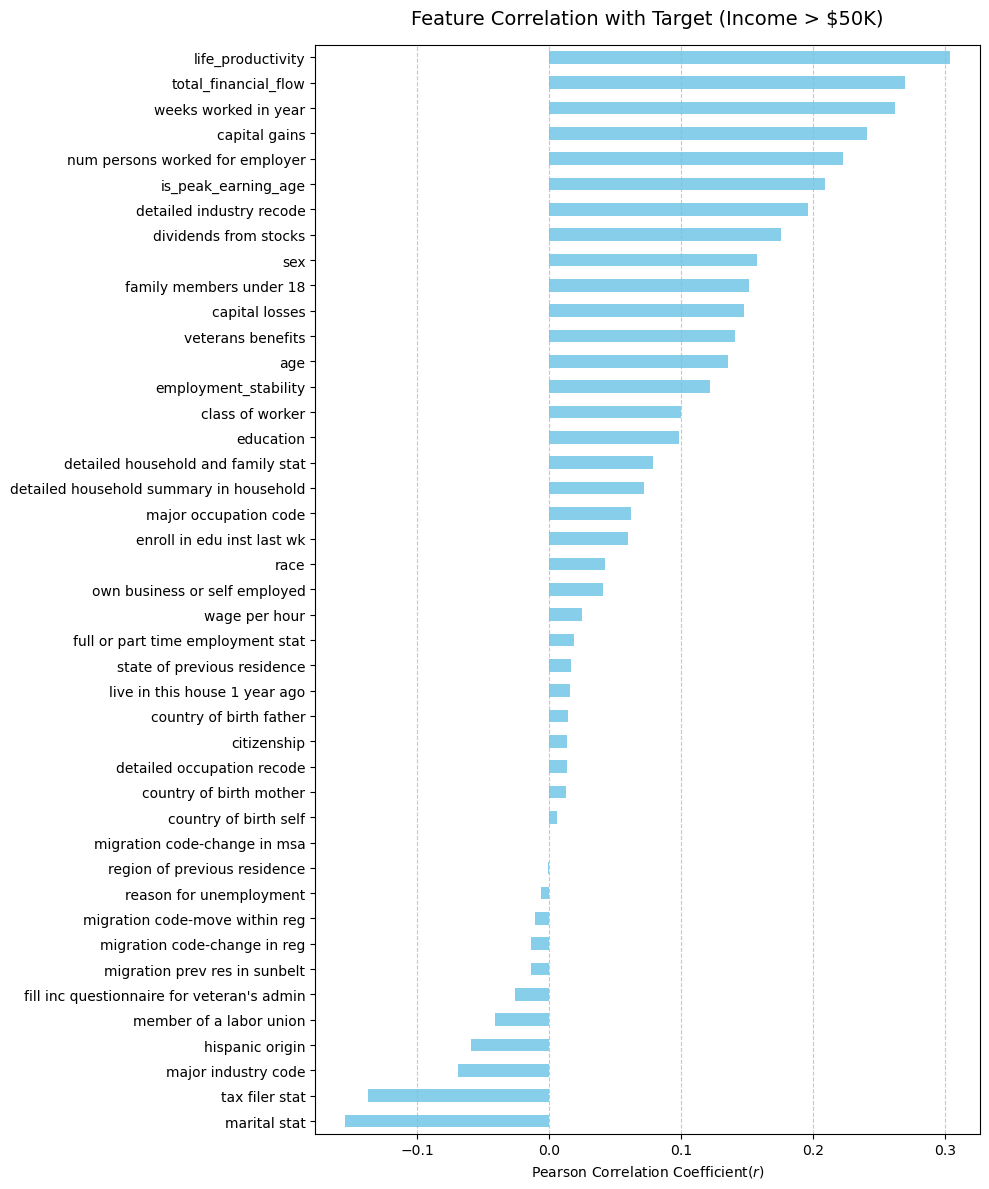

In [ ]:
# feature correlation with target
target_corr = corr_matrix['target'].drop('target').sort_values(ascending=True)

plt.figure(figsize=(10, 12))
target_corr.plot(kind='barh', color='skyblue')
plt.title('Feature Correlation with Target (Income > $50K)', fontsize=14, pad=15)
plt.xlabel('Pearson Correlation Coefficient($r$)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('feature_target_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

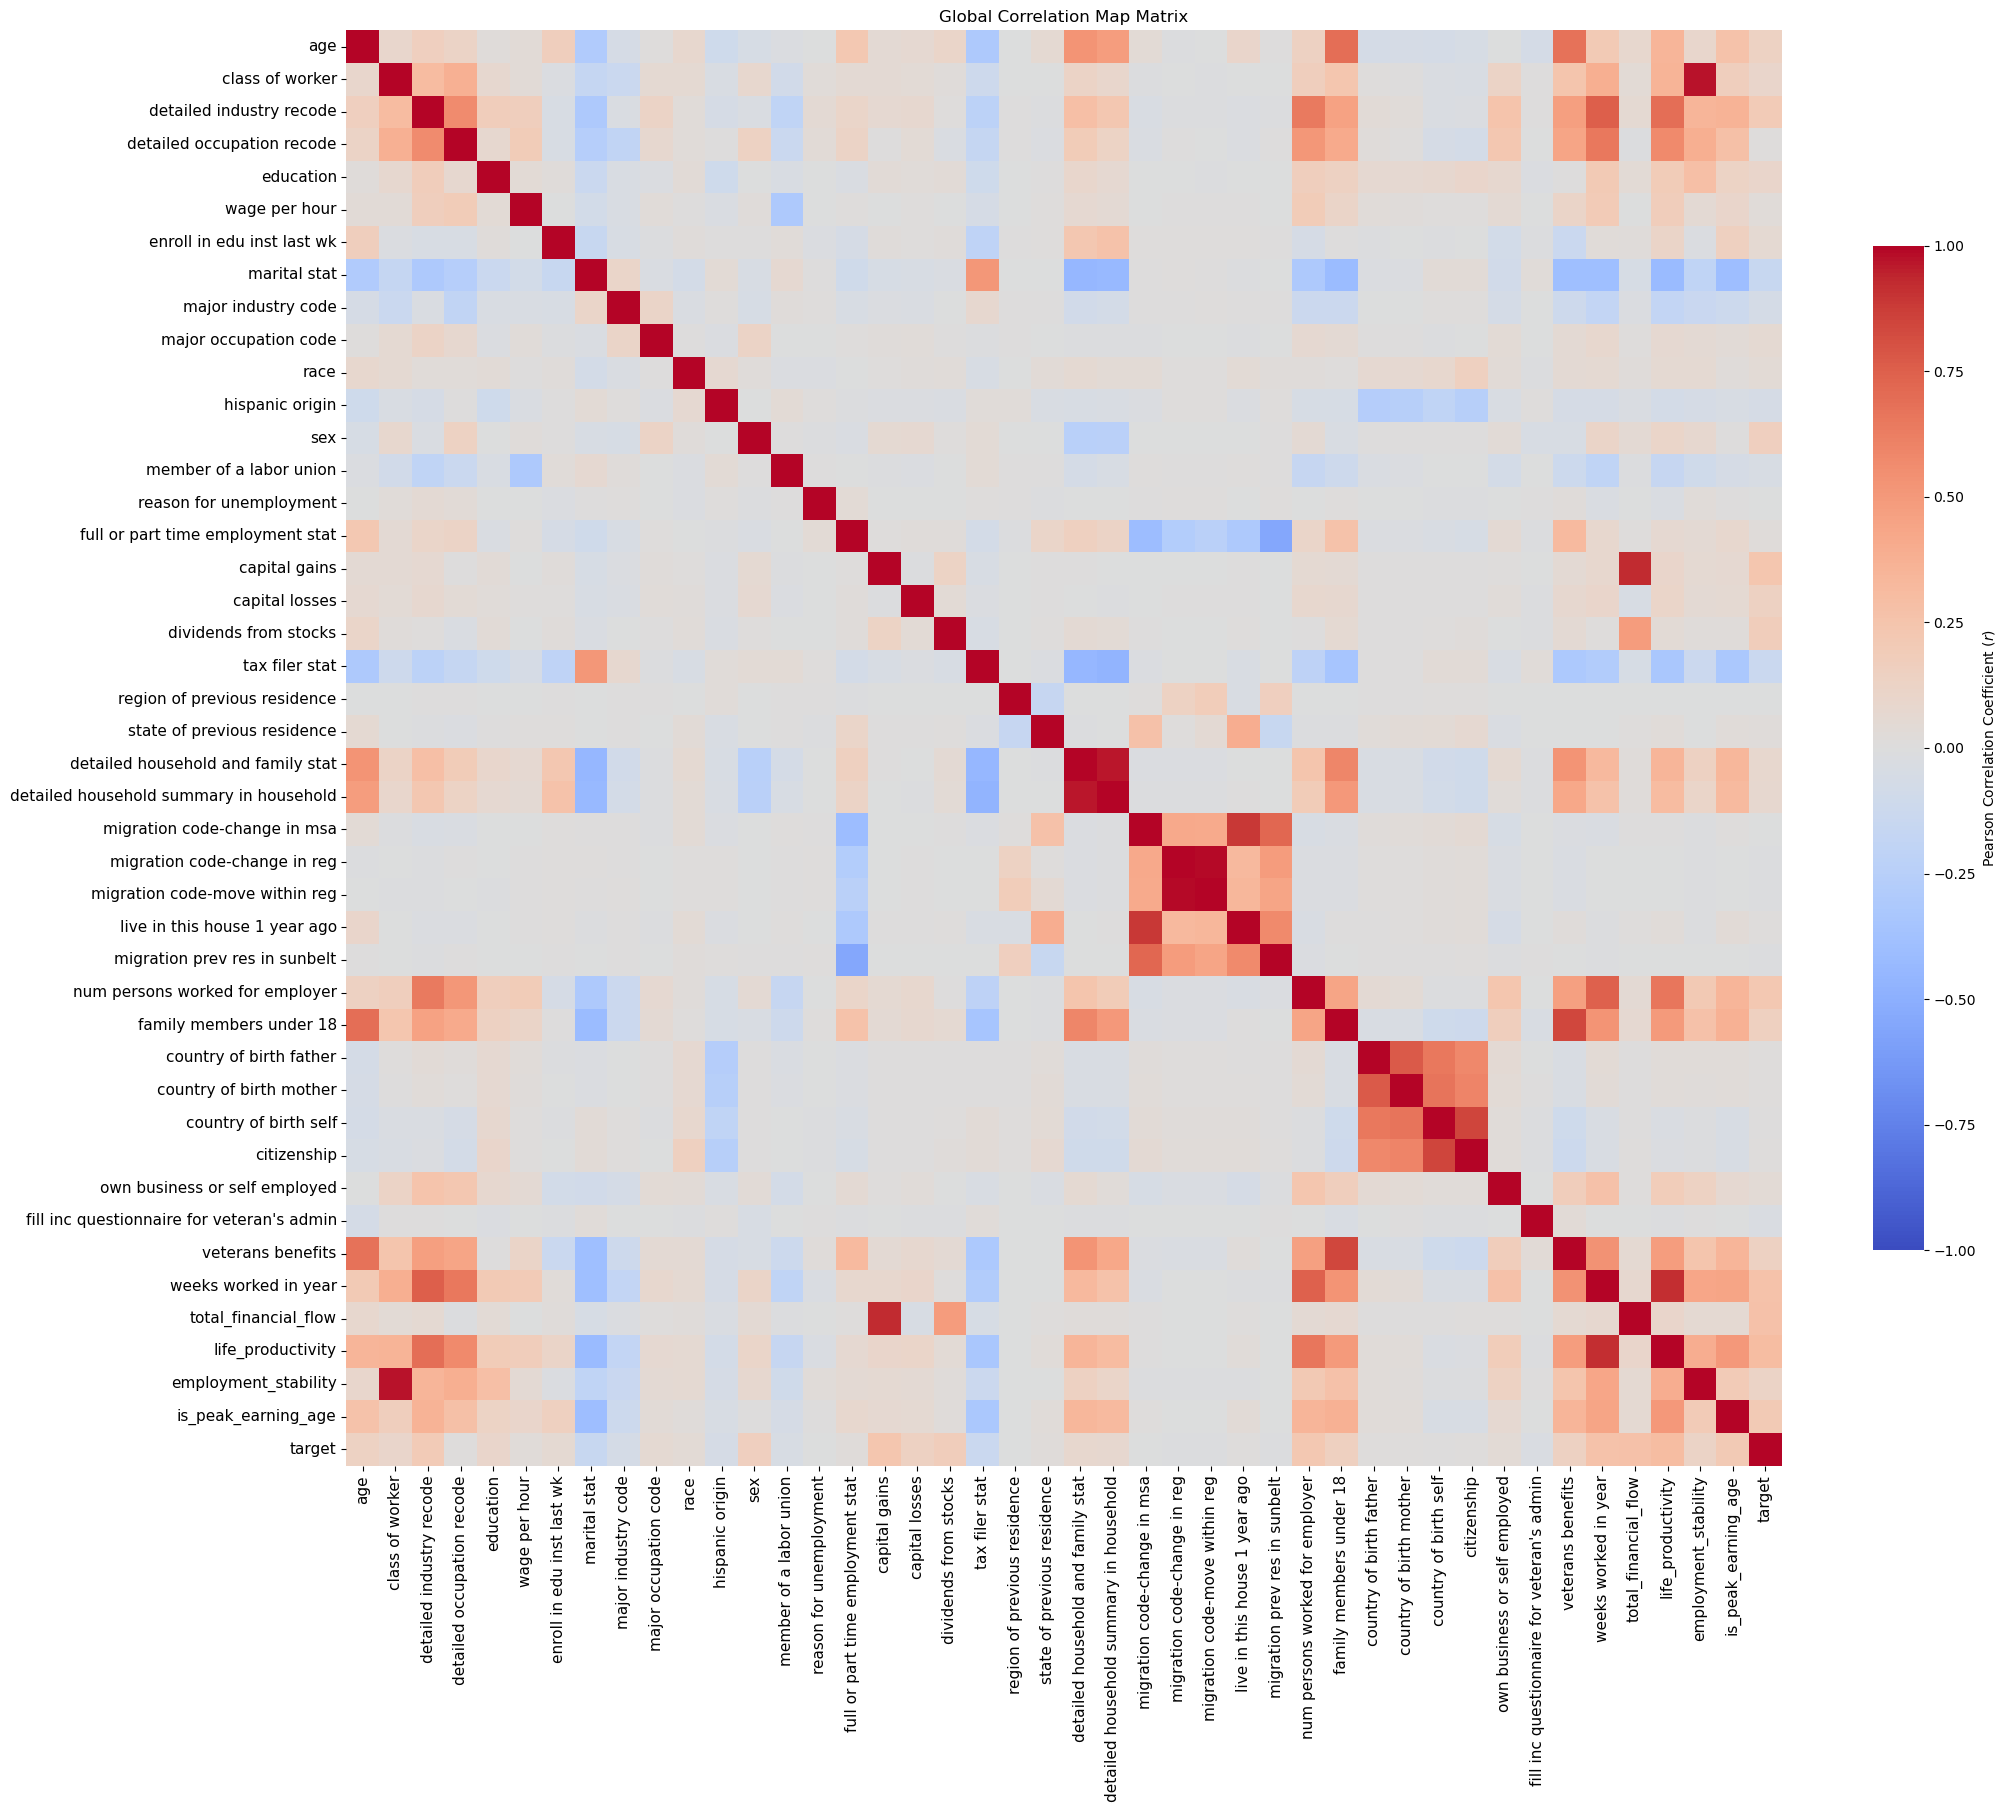

In [ ]:
# correlation matrix
plt.figure(figsize=(22, 18))

sns.heatmap(
    corr_matrix, 
    annot=False,
    cmap='coolwarm',
    square=True,
    vmin=-1, vmax=1,
    cbar_kws={'shrink': 0.7, 'label': 'Pearson Correlation Coefficient ($r$)'}
)

plt.title('Global Correlation Map Matrix')

# label rotation and font sixes for readability
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
# plt.savefig(global_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## Classification Task

In [ ]:
# split data
# 80% train & validation / 20% test
X_temp, X_test, y_temp, y_test, w_temp, w_test = train_test_split(
    X, y, weights, test_size=0.20, random_state=42, stratify=y
)

# take 20% from 80% split earlier for validation (total: 60% train/20% test/20% val)
X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(
    X_temp, y_temp, w_temp, test_size=0.25, random_state=42, stratify=y_temp
)

In [ ]:
# train model
# scale_pos_weight helps with class imbalance
ratio = np.sum(y == 0) / np.sum(y == 1)

# grid search setup
weighted_logloss = make_scorer(
    log_loss,
    response_method='predict_proba',
    greater_is_better=False,
)

param_grid = {
    'max_depth': [6, 8, 10, 12],
    'learning_rate': [0.03, 0.05],
    'n_estimators': [100, 200, 300],
    'colsample_bytree': [0.7, 0.8]
    
}

# base classifier setup
base_classifier = XGBClassifier(
    scale_pos_weight=ratio,
    subsample=0.8, # prevents rows from forcing overfit
    random_state=42,
    eval_metric=['logloss']
)

grid_search = GridSearchCV(
    estimator=base_classifier,
    param_grid=param_grid,
    scoring=weighted_logloss,
    cv=3,
    verbose=1,
    n_jobs=1,
)

grid_search.fit(
    X_temp, y_temp, 
    sample_weight=w_temp
)
print('Optimal Hyperparameters:', grid_search.best_params_)

# grab best settings and initialize deep execution run
best_settings = grid_search.best_params_
best_settings['scale_pos_weight'] = ratio
best_settings['subsample'] = 0.8
best_settings['random_state'] = 42
best_settings['eval_metric'] = ['logloss', 'error']
best_settings['early_stopping_rounds'] = 50
best_settings['n_estimators'] = 1000

classifier = XGBClassifier(**best_settings)

classifier.fit(
    X_train, y_train,
    sample_weight=w_train, 
    eval_set=[(X_train, y_train), (X_val, y_val)],
    sample_weight_eval_set=[w_train, w_val],
    verbose=10
)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Optimal Hyperparameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 12, 'n_estimators': 300}
[0]	validation_0-logloss:0.67076	validation_0-error:0.15554	validation_1-logloss:0.67215	validation_1-error:0.17200
[10]	validation_0-logloss:0.44345	validation_0-error:0.10125	validation_1-logloss:0.45442	validation_1-error:0.11660
[20]	validation_0-logloss:0.33000	validation_0-error:0.09286	validation_1-logloss:0.34863	validation_1-error:0.10990
[30]	validation_0-logloss:0.26669	validation_0-error:0.08806	validation_1-logloss:0.29132	validation_1-error:0.10502
[40]	validation_0-logloss:0.22584	validation_0-error:0.08164	validation_1-logloss:0.25650	validation_1-error:0.10115
[50]	validation_0-logloss:0.19964	validation_0-error:0.07741	validation_1-logloss:0.23532	validation_1-error:0.09827
[60]	validation_0-logloss:0.18351	validation_0-error:0.07421	validation_1-logloss:0.22286	validation_1-error:0.09590
[70]	val

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric=['logloss', 'error'],
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=12, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

Final Evaluation
              precision    recall  f1-score   support

           0       0.97      0.98      0.97 64953101.679999925
           1       0.61      0.54      0.57 4483480.5600000145

    accuracy                           0.95 69436582.23999994
   macro avg       0.79      0.76      0.77 69436582.23999994
weighted avg       0.95      0.95      0.95 69436582.23999994



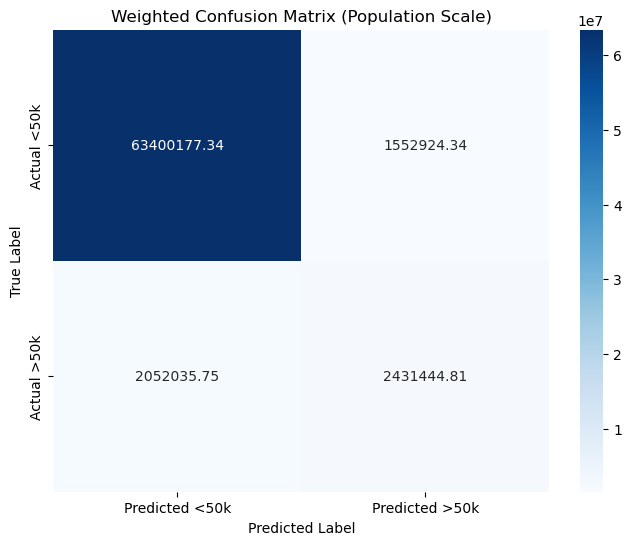

Top 10 Predictive Variables for Income
family members under 18                    0.349104
life_productivity                          0.063313
weeks worked in year                       0.052884
num persons worked for employer            0.031777
sex                                        0.031248
total_financial_flow                       0.027960
detailed occupation recode                 0.024092
capital losses                             0.018719
detailed household summary in household    0.017685
major occupation code                      0.016415
dtype: float32


In [ ]:
# validation & evaluation
print("Final Evaluation")
y_pred = classifier.predict(X_test)
print(classification_report(y_test, y_pred, sample_weight=w_test)) # use sample_weight in report to reflect population distribution

# confusion matrix visualization
cm = confusion_matrix(y_test, y_pred, sample_weight=w_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Predicted <50k', 'Predicted >50k'],
            yticklabels=['Actual <50k', 'Actual >50k'])
plt.title('Weighted Confusion Matrix (Population Scale)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


important_features = pd.Series(classifier.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 10 Predictive Variables for Income")
print(important_features.head(10))

### Notes
#### Implementation:
* class 0 high precision (0.99) high recall (0.91)
* class 1 low precision (0.38) acceptable recall (0.83)
* overall accuracy 0.90

ways to adjust:
1) adjust classification threshold
2) lower/remove scale_pos_weight, may decrease recall
3) feature engineering

---

#### Fix 1: adjust classification threshold(0.75)
Result: precision of class 0 decreased (0.98) and recall increased (0.96), increases precision (0.54) of class 1 but lowers recall (0.69), overall accuracy 0.94

#### Fix 2: slower learning_rate 0.05 -> 0.03, max_depth 6 -> 7, scale_pos_weight=1, added max_delta_step=1
Result: Overly conservative model, never predicts 1

#### Fix 2b: sqrt ratio, added subsample=0.8, added colsample_bytree=0.8*
Result: class 0 precision 0.96, recall 0.99; class 1 precision 0.69, recall 0.38; overall accuracy 0.95

#### Fix 3: feature engineering (total_financial_flow, life_productivity, employment_stability, is_peak_earning_age)
Result: class 0 precision same, recall +0.1; class 1 precision +0.2, recall -0.2; overall accuracy 0.91
* improved fundamental predictablility
* model uses engineered metrics to spot high earners

### Next Steps
* explore cross validation
* options:
    1) use the model as is, captures majority of the available wealth in the population; option comprehensive customer discovery and retention -> capture
    2) more feature engineering 
    3) reintroduce custom probability threshold for higher precision; option for direct marketing and targeted campaigns -> conversion

## Segmentation Task

In [4]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

In [13]:
# preprocessing
df_km = df.replace('?', 'NA') # handle missing values

# separate metadata from features
X_raw = df_km.drop(['label', 'weight', 'year'], axis=1).copy()
w_km = df_km['weight'].values

# isolate continuous numerical features for scaling
numeric_features = [
    'age', 'wage per hour', 'capital gains', 'capital losses', 'dividends from stocks',
    'num persons worked for employer', 'weeks worked in year'
]

# remaining treated as categorical column for one-hot encoding
categorical_features = [col for col in X_raw.columns if col not in numeric_features]

# construct parallel processing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='NA')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ]
)

X_scaled_km = preprocessor.fit_transform(X_raw)
X_scaled_km.shape

(199523, 508)

K=1, Inertia:770019624.35
K=2, Inertia:643222559.29
K=3, Inertia:598032055.45
K=4, Inertia:543933688.97
K=5, Inertia:502124377.14
K=6, Inertia:480084666.97
K=7, Inertia:450878518.30
K=8, Inertia:436560104.76
K=9, Inertia:415572326.95
K=10, Inertia:415071792.38
K=11, Inertia:387692669.00
K=12, Inertia:367947256.60
K=13, Inertia:357865205.34
K=14, Inertia:351461518.76


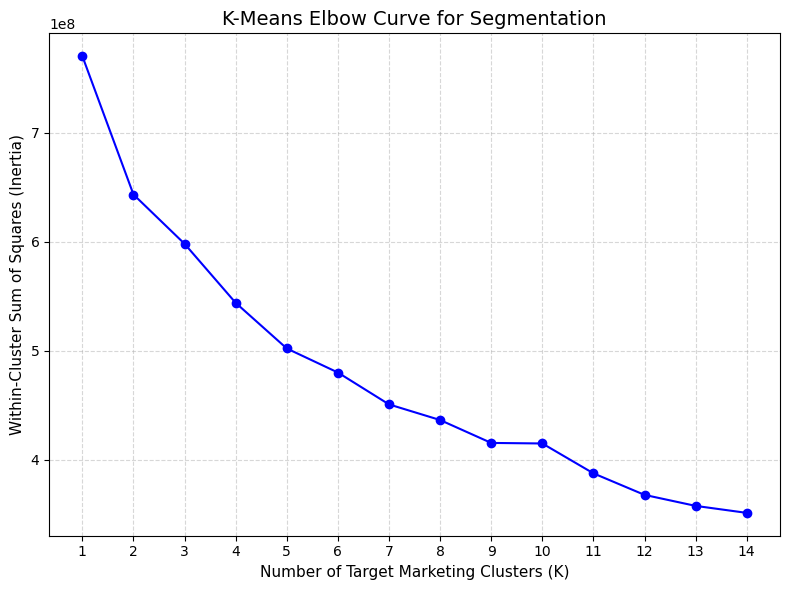

In [14]:
# find optimal number of clusters
# 10% representative sample to compute elbow curve efficiently
sample_size = int(len(X_scaled_km) * 0.10)
np.random.seed(42)
sample_indices = np.random.choice(len(X_scaled_km), size=sample_size, replace=False)

X_sample = X_scaled_km[sample_indices]
w_sample = w_km[sample_indices]

# run elbow loop
inertia_scores = []
k_range = range(1, 15)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=100)
    kmeans_test.fit(X_sample, sample_weight=w_sample)
    inertia_scores.append(kmeans_test.inertia_)
    print(f'K={k}, Inertia:{kmeans_test.inertia_:.2f}')
    
# plot elbow curve
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia_scores, marker='o', linestyle='-', color='blue')
plt.title('K-Means Elbow Curve for Segmentation', fontsize=14)
plt.xlabel('Number of Target Marketing Clusters (K)', fontsize=11)
plt.ylabel('Within-Cluster Sum of Squares (Inertia)', fontsize=11)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


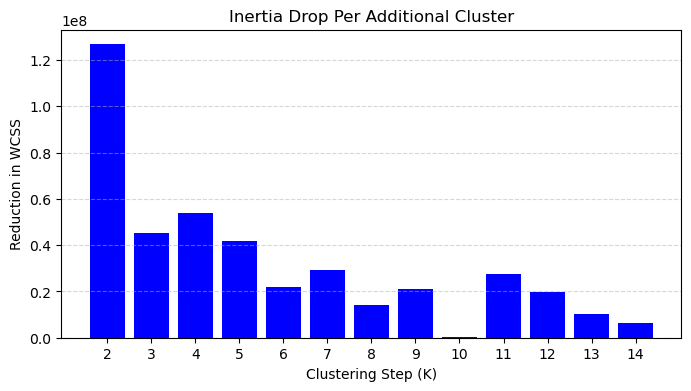

In [12]:
# inertia delta
inertia_drops = np.diff(inertia_scores)
plt.figure(figsize=(8, 4))
plt.bar(range(2, 15), -inertia_drops, color='blue')
plt.title('Inertia Drop Per Additional Cluster')
plt.xlabel('Clustering Step (K)')
plt.ylabel('Reduction in WCSS')
plt.xticks(range(2, 15))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
selected_k = 5
k_means_final = KMeans(n_clusters=selected_k, random_state=42, n_init=10, max_iter=300)

# fit final model with selected k on entire population
k_means_final.fit(X_scaled_km, sample_weight=w_km)

# assign cluster labels to unscaled dataframe
df_km['cluster_id'] = k_means_final.labels_

# calculate population-weighted averages for each cluster
cluster_profiles = df_km.groupby('cluster_id')[numeric_features].mean()
cluster_profiles = cluster_profiles.T

print('Weighted Averages Per Cluster:\n', cluster_profiles.round(2))

marketing_categories = ['education', 'marital stat', 'class of worker', 'major occupation code', 'sex']
print('Dominant Categorical Traits Per Cluster')
# calculate the most common text lable for each category within each cluster
for cat in marketing_categories:
    print(f'\nMost Commmon {cat.title()}:')
    for cluster in range(5):
        cluster_data = df_km[df_km['cluster_id'] == cluster]
    # find category with highest sum of population weights
    top_category = cluster_data.groupby(cat)['weight'].sum().idxmax()
    print(f'Cluster {cluster}: {top_category}')

# calculate real-world population size of each group
cluster_sizes = df_km.groupby('cluster_id')['weight'].sum()
print('\nActual Population Size Per Cluster:')
print(cluster_sizes.map('{:,.0f}'.format))

Weighted Averages Per Cluster:
 cluster_id                            0     1        2       3       4
age                               38.44  8.06    44.28   57.55   38.28
wage per hour                    111.75  0.10    74.17    0.00  107.95
capital gains                    442.05  0.74  9314.90  146.20  400.09
capital losses                     0.40  0.00  1757.86    0.47    0.34
dividends from stocks            175.26  0.80  1353.58  383.50  171.41
num persons worked for employer    3.78  0.05     3.45    0.24    3.63
weeks worked in year              44.98  0.21    42.21    1.46   44.43

Actual Population Size Per Cluster:
cluster_id
0    87,064,767
1    90,303,894
2     7,579,266
3    75,635,917
4    86,662,049
Name: weight, dtype: object


In [27]:
# custom age brackets to see the generational split
age_bins = [0, 17, 29, 54, 100]
age_labels = ['Youth (0-17)', 'Young Adults (18-29)', 'Peak Career (30-54)', 'Seniors (55+)']

df_km['age_group'] = pd.cut(df_km['age'], bins=age_bins, labels=age_labels)

# weighted cross-tabulation table
generational_mix = pd.crosstab(
    index=df_km['age_group'],
    columns=df_km['cluster_id'],
    values=df_km['weight'],
    aggfunc='sum'
).fillna(0)

print("Generational Representation in Each Group")
print(generational_mix.map('{:,.0f}'.format))

Generational Representation in Each Group
cluster_id                     0           1          2           3           4
age_group                                                                      
Youth (0-17)           1,831,925  84,735,586    139,423     188,044   1,641,607
Young Adults (18-29)  23,314,546     380,637  1,210,045  10,408,194  24,104,982
Peak Career (30-54)   51,534,745           0  4,502,354  18,874,471  50,629,375
Seniors (55+)         10,383,552           0  1,727,444  46,165,208  10,286,084


## Resources
https://xgboost.readthedocs.io/en/release_3.2.0/tutorials/model.html

https://xgboost.readthedocs.io/en/stable/parameter.html

https://medium.com/data-science/stop-saying-precision-and-recall-to-business-leaders-f17082ab5052

https://www.adpresearch.com/research/the-wage-lifecycle-is-more-complex-than-you-think

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html